<a href="https://colab.research.google.com/github/JPAmewu/My_Capstone_1_Imperial/blob/main/Week_7_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
# Import Libraries and Check Google Drive files

import os
import zipfile
import shutil
import numpy as np

drive_folder = "/content/drive/MyDrive/capstone_backup/"

In [78]:
# Extract the full Week_6_dataset

week_6_zip = drive_folder + "week_6_data.zip"
week_6_dataset_path = "/content/week_6_data"

os.makedirs(week_6_dataset_path, exist_ok=True)

with zipfile.ZipFile(week_6_zip, "r") as zip_ref:
    zip_ref.extractall(week_6_dataset_path)

print("Week 6 dataset extracted successfully.")
os.listdir(week_6_dataset_path)

Week 6 dataset extracted successfully.


['function_5_outputs.npy',
 'function_1_inputs.npy',
 'function_4_inputs.npy',
 'function_1_outputs.npy',
 'function_6_outputs.npy',
 'function_2_inputs.npy',
 'function_8_inputs.npy',
 'function_8_outputs.npy',
 'function_6_inputs.npy',
 'function_2_outputs.npy',
 'function_5_inputs.npy',
 'function_7_outputs.npy',
 'function_7_inputs.npy',
 'function_3_inputs.npy',
 'function_3_outputs.npy',
 'function_4_outputs.npy']

In [79]:
# Check old Week_6_dataset

for f in range(1, 9):
    X_old = np.load(
        week_6_dataset_path + f"/function_{f}_inputs.npy",
        allow_pickle=True
    )

    y_old = np.load(
        week_6_dataset_path + f"/function_{f}_outputs.npy",
        allow_pickle=True
    )

    print(f"Function {f}")
    print("Old input shape:", X_old.shape)
    print("Old output shape:", y_old.shape)
    print()

Function 1
Old input shape: (15, 2)
Old output shape: (15,)

Function 2
Old input shape: (15, 2)
Old output shape: (15,)

Function 3
Old input shape: (20, 3)
Old output shape: (20,)

Function 4
Old input shape: (35, 4)
Old output shape: (35,)

Function 5
Old input shape: (25, 4)
Old output shape: (25,)

Function 6
Old input shape: (25, 5)
Old output shape: (25,)

Function 7
Old input shape: (35, 6)
Old output shape: (35,)

Function 8
Old input shape: (45, 8)
Old output shape: (45,)



In [80]:
# Enter Week_6_dataset Inputs and Outputs

week_6_new_inputs = {
    1: np.array([0.897714, 0.081699]),
    2: np.array([0.555332, 0.360931]),
    3: np.array([0.522231, 0.090709, 0.451742]),
    4: np.array([0.713766, 0.198601, 0.014095, 0.068347]),
    5: np.array([0.754614, 0.504566, 0.432986, 0.307039]),
    6: np.array([0.824244, 0.022732, 0.960907, 0.041715, 0.897560]),
    7: np.array([0.052337, 0.910075, 0.727790, 0.075231, 0.386516, 0.492629]),
    8: np.array([0.110992, 0.462977, 0.255313, 0.963757, 0.895383, 0.716713, 0.030436, 0.083412])
}

week_6_new_outputs = {
    1: 7.651210225556565e-239,
    2: 0.22078072799826579,
    3: -0.05739710166867316,
    4: -17.92630659900679,
    5: 0.9401160531598542,
    6: -2.5293691850310744,
    7: 0.19078262729854223,
    8: 9.1386093133071
}

In [81]:
# Append to Create Week_7_dataset

week_7_dataset_path = "/content/week_7_data"
os.makedirs(week_7_dataset_path, exist_ok=True)

week_7_dataset_inputs = {}
week_7_dataset_outputs = {}

for f in range(1, 9):
    # Load old Week 6 dataset
    X_old = np.load(
        week_6_dataset_path + f"/function_{f}_inputs.npy",
        allow_pickle=True
    )

    y_old = np.load(
        week_6_dataset_path + f"/function_{f}_outputs.npy",
        allow_pickle=True
    )

    # Prepare new Week 6 input/output
    X_new = week_6_new_inputs[f].reshape(1, -1)
    y_new = np.array([week_6_new_outputs[f]])

    # Check that dimensions match
    if X_old.shape[1] != X_new.shape[1]:
        raise ValueError(
            f"Function {f}: dimension mismatch. "
            f"Old has {X_old.shape[1]}, new has {X_new.shape[1]}"
        )

    # Append old + new
    week_7_dataset_inputs[f] = np.vstack([X_old, X_new])
    week_7_dataset_outputs[f] = np.concatenate([y_old, y_new])

    # Save files
    np.save(
        week_7_dataset_path + f"/function_{f}_inputs.npy",
        week_7_dataset_inputs[f],
        allow_pickle=True
    )

    np.save(
        week_7_dataset_path + f"/function_{f}_outputs.npy",
        week_7_dataset_outputs[f],
        allow_pickle=True
    )

    print(f"Function {f}")
    print("Old input shape:", X_old.shape)
    print("New input shape:", X_new.shape)
    print("Week 7 input shape:", week_7_dataset_inputs[f].shape)
    print("Old output shape:", y_old.shape)
    print("New output shape:", y_new.shape)
    print("Week 7 output shape:", week_7_dataset_outputs[f].shape)
    print()

Function 1
Old input shape: (15, 2)
New input shape: (1, 2)
Week 7 input shape: (16, 2)
Old output shape: (15,)
New output shape: (1,)
Week 7 output shape: (16,)

Function 2
Old input shape: (15, 2)
New input shape: (1, 2)
Week 7 input shape: (16, 2)
Old output shape: (15,)
New output shape: (1,)
Week 7 output shape: (16,)

Function 3
Old input shape: (20, 3)
New input shape: (1, 3)
Week 7 input shape: (21, 3)
Old output shape: (20,)
New output shape: (1,)
Week 7 output shape: (21,)

Function 4
Old input shape: (35, 4)
New input shape: (1, 4)
Week 7 input shape: (36, 4)
Old output shape: (35,)
New output shape: (1,)
Week 7 output shape: (36,)

Function 5
Old input shape: (25, 4)
New input shape: (1, 4)
Week 7 input shape: (26, 4)
Old output shape: (25,)
New output shape: (1,)
Week 7 output shape: (26,)

Function 6
Old input shape: (25, 5)
New input shape: (1, 5)
Week 7 input shape: (26, 5)
Old output shape: (25,)
New output shape: (1,)
Week 7 output shape: (26,)

Function 7
Old input s

In [82]:
# Zip Week_7_dataset

week_7_zip_path = "/content/week_7_data.zip"

with zipfile.ZipFile(week_7_zip_path, "w") as zipf:
    for file_name in os.listdir(week_7_dataset_path):
        file_path = os.path.join(week_7_dataset_path, file_name)
        zipf.write(file_path, arcname=file_name)

print("Week 7 dataset zipped successfully.")

Week 7 dataset zipped successfully.


In [83]:
# Save Week_7_dataset to Google Drive

drive_save_path = drive_folder + "week_7_data.zip"

shutil.copy(week_7_zip_path, drive_save_path)

print("True Week 7 dataset saved to Google Drive successfully.")

True Week 7 dataset saved to Google Drive successfully.


In [84]:
# Week_7_datase is saved

week_7_check_path = "/content/week_7_check"
os.makedirs(week_7_check_path, exist_ok=True)

with zipfile.ZipFile(drive_folder + "week_7_data.zip", "r") as zip_ref:
    zip_ref.extractall(week_7_check_path)

for f in range(1, 9):
    X = np.load(
        week_7_check_path + f"/function_{f}_inputs.npy",
        allow_pickle=True
    )

    y = np.load(
        week_7_check_path + f"/function_{f}_outputs.npy",
        allow_pickle=True
    )

    print(f"Function {f}")
    print("Input shape:", X.shape)
    print("Output shape:", y.shape)
    print()

Function 1
Input shape: (16, 2)
Output shape: (16,)

Function 2
Input shape: (16, 2)
Output shape: (16,)

Function 3
Input shape: (21, 3)
Output shape: (21,)

Function 4
Input shape: (36, 4)
Output shape: (36,)

Function 5
Input shape: (26, 4)
Output shape: (26,)

Function 6
Input shape: (26, 5)
Output shape: (26,)

Function 7
Input shape: (36, 6)
Output shape: (36,)

Function 8
Input shape: (46, 8)
Output shape: (46,)



In [85]:
# Week 7 dataset extracted for EDA.

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive_folder = "/content/drive/MyDrive/capstone_backup/"
week_7_zip = drive_folder + "week_7_data.zip"

week_7_path = "/content/week_7_eda"
os.makedirs(week_7_path, exist_ok=True)

with zipfile.ZipFile(week_7_zip, "r") as zip_ref:
    zip_ref.extractall(week_7_path)

print("Week 7 dataset extracted for EDA.")
print(os.listdir(week_7_path))

Week 7 dataset extracted for EDA.
['function_5_outputs.npy', 'function_1_inputs.npy', 'function_4_inputs.npy', 'function_1_outputs.npy', 'function_6_outputs.npy', 'function_2_inputs.npy', 'function_8_inputs.npy', 'function_8_outputs.npy', 'function_6_inputs.npy', 'function_2_outputs.npy', 'function_5_inputs.npy', 'function_7_outputs.npy', 'function_7_inputs.npy', 'function_3_inputs.npy', 'function_3_outputs.npy', 'function_4_outputs.npy']


In [86]:
# Check what type the loaded input has

import numpy as np
import os
import zipfile
import pandas as pd

week_7_path = "/content/week_7_eda"

for f in range(1, 9):
    X = np.load(
        week_7_path + f"/function_{f}_inputs.npy",
        allow_pickle=True
    )

    y = np.load(
        week_7_path + f"/function_{f}_outputs.npy",
        allow_pickle=True
    )

    print(f"Function {f}")
    print("X type:", type(X))
    print("X dtype:", X.dtype)
    print("X shape:", X.shape)
    print("First X item:", X[0])
    print("y dtype:", y.dtype)
    print("y shape:", y.shape)
    print()

Function 1
X type: <class 'numpy.ndarray'>
X dtype: object
X shape: (16, 2)
First X item: [0.31940388883889725 0.7629593742689353]
y dtype: float64
y shape: (16,)

Function 2
X type: <class 'numpy.ndarray'>
X dtype: object
X shape: (16, 2)
First X item: [0.6657995800131589 0.12396912767534907]
y dtype: float64
y shape: (16,)

Function 3
X type: <class 'numpy.ndarray'>
X dtype: object
X shape: (21, 3)
First X item: [0.1715252068810621 0.3439168702758373 0.2487372010692387]
y dtype: float64
y shape: (21,)

Function 4
X type: <class 'numpy.ndarray'>
X dtype: object
X shape: (36, 4)
First X item: [0.8969810543559719 0.7256279703482243 0.17540430890241154
 0.7016943693717497]
y dtype: float64
y shape: (36,)

Function 5
X type: <class 'numpy.ndarray'>
X dtype: object
X shape: (26, 4)
First X item: [0.1914470844571281 0.03819337135150802 0.6074178108720669
 0.4145841369758819]
y dtype: float64
y shape: (26,)

Function 6
X type: <class 'numpy.ndarray'>
X dtype: object
X shape: (26, 5)
First X 

In [87]:
# Create clean helper functions

import numpy as np
import pandas as pd
import re

def clean_X(X):
    rows = []

    for row in X:
        try:
            row_clean = np.array(row, dtype=float).flatten()
        except:
            text = str(row)
            numbers = re.findall(r"[-+]?\d*\.?\d+(?:e[-+]?\d+)?", text)
            row_clean = np.array([float(n) for n in numbers])

        rows.append(row_clean)

    return np.vstack(rows)


def clean_y(y):
    values = []

    for value in y:
        try:
            values.append(float(value))
        except:
            text = str(value)
            numbers = re.findall(r"[-+]?\d*\.?\d+(?:e[-+]?\d+)?", text)
            values.append(float(numbers[-1]))

    return np.array(values, dtype=float)

In [88]:
# Create EDA summary table

summary = []

for f in range(1, 9):
    X = np.load(
        week_7_path + f"/function_{f}_inputs.npy",
        allow_pickle=True
    )

    y = np.load(
        week_7_path + f"/function_{f}_outputs.npy",
        allow_pickle=True
    )

    summary.append({
        "Function": f"Function {f}",
        "Input shape": X.shape,
        "Output shape": y.shape,
        "Number of query points": X.shape[0],
        "Dimensions": X.shape[1],
        "Best output so far": np.max(y),
        "Worst output so far": np.min(y),
        "Mean output": np.mean(y),
        "Median output": np.median(y),
        "Standard deviation": np.std(y),
        "Best point index": np.argmax(y)
    })

week_7_summary_df = pd.DataFrame(summary)
week_7_summary_df

,Function,Input shape,Output shape,Number of query points,Dimensions,Best output so far,Worst output so far,Mean output,Median output,Standard deviation,Best point index
0,Function 1,"(16, 2)","(16,)",16,2,64.000000,-0.003606,15.999775,3.114928e-48,27.712943,10
1,Function 2,"(16, 2)","(16,)",16,2,64.000000,-0.065624,4.171769,2.178726e-01,15.448865,13
2,Function 3,"(21, 3)","(21,)",21,3,64.000000,-0.398926,12.108462,-5.739710e-02,25.171198,15
3,Function 4,"(36, 4)","(36,)",36,4,64.000000,-32.625660,-13.586270,-1.575674e+01,15.353443,33
4,Function 5,"(26, 4)","(26,)",26,4,1088.859618,0.112940,126.281452,6.400000e+01,220.626598,15
5,Function 6,"(26, 5)","(26,)",26,5,64.000000,-2.571170,1.111952,-1.332899e+00,12.596411,23
6,Function 7,"(36, 6)","(36,)",36,6,64.000000,0.002701,7.304716,9.795888e-02,20.046708,30
7,Function 8,"(46, 8)","(46,)",46,8,64.000000,-8.727516,8.015340,7.889150e+00,9.342797,43


In [89]:
# Find the bad row

for f in range(1, 9):
    X_raw = np.load(
        week_7_path + f"/function_{f}_inputs.npy",
        allow_pickle=True
    )

    print(f"\nFunction {f}")

    for i, row in enumerate(X_raw):
        try:
            arr = np.array(row, dtype=float).flatten()
        except:
            text = str(row)
            numbers = re.findall(r"[-+]?\d*\.?\d+(?:e[-+]?\d+)?", text)
            arr = np.array([float(n) for n in numbers])

        print(f"Row {i}: size {arr.size}")


Function 1
Row 0: size 2
Row 1: size 2
Row 2: size 2
Row 3: size 2
Row 4: size 2
Row 5: size 2
Row 6: size 2
Row 7: size 2
Row 8: size 2
Row 9: size 2
Row 10: size 2
Row 11: size 2
Row 12: size 2
Row 13: size 2
Row 14: size 2
Row 15: size 2

Function 2
Row 0: size 2
Row 1: size 2
Row 2: size 2
Row 3: size 2
Row 4: size 2
Row 5: size 2
Row 6: size 2
Row 7: size 2
Row 8: size 2
Row 9: size 2
Row 10: size 2
Row 11: size 2
Row 12: size 2
Row 13: size 2
Row 14: size 2
Row 15: size 2

Function 3
Row 0: size 3
Row 1: size 3
Row 2: size 3
Row 3: size 3
Row 4: size 3
Row 5: size 3
Row 6: size 3
Row 7: size 3
Row 8: size 3
Row 9: size 3
Row 10: size 3
Row 11: size 3
Row 12: size 3
Row 13: size 3
Row 14: size 3
Row 15: size 3
Row 16: size 3
Row 17: size 3
Row 18: size 3
Row 19: size 3
Row 20: size 3

Function 4
Row 0: size 4
Row 1: size 4
Row 2: size 4
Row 3: size 4
Row 4: size 4
Row 5: size 4
Row 6: size 4
Row 7: size 4
Row 8: size 4
Row 9: size 4
Row 10: size 4
Row 11: size 4
Row 12: size 4
Ro

In [90]:
# Use a safer cleaning function that skips bad rows

def clean_X_with_expected_dim(X, expected_dim):
    clean_rows = []
    valid_indices = []
    bad_rows = []

    for i, row in enumerate(X):
        try:
            arr = np.array(row, dtype=float).flatten()
        except:
            text = str(row)
            numbers = re.findall(r"[-+]?\d*\.?\d+(?:e[-+]?\d+)?", text)
            arr = np.array([float(n) for n in numbers])

        if arr.size == expected_dim:
            clean_rows.append(arr)
            valid_indices.append(i)
        else:
            bad_rows.append((i, arr.size, arr))

    return np.vstack(clean_rows), np.array(valid_indices), bad_rows

In [91]:
# Rebuild the best query point table safely

best_points = []

for f in range(1, 9):
    X_raw = np.load(
        week_7_path + f"/function_{f}_inputs.npy",
        allow_pickle=True
    )

    y_raw = np.load(
        week_7_path + f"/function_{f}_outputs.npy",
        allow_pickle=True
    )

    y = clean_y(y_raw)

    # Expected dimension for this function
    expected_dim = {
        1: 2,
        2: 2,
        3: 3,
        4: 4,
        5: 4,
        6: 5,
        7: 6,
        8: 8
    }[f]

    X, valid_indices, bad_rows = clean_X_with_expected_dim(X_raw, expected_dim)

    # Keep only y values that match valid X rows
    y_valid = y[valid_indices]

    best_index_inside_clean_data = np.argmax(y_valid)
    original_best_index = valid_indices[best_index_inside_clean_data]

    best_points.append({
        "Function": f"Function {f}",
        "Best point index": original_best_index,
        "Best query point": X[best_index_inside_clean_data],
        "Best output": y_valid[best_index_inside_clean_data],
        "Bad rows removed": bad_rows
    })

best_points_df = pd.DataFrame(best_points)
best_points_df

,Function,Best point index,Best query point,Best output,Bad rows removed
0,Function 1,10,"[0.37454, 0.950714]",64.000000,[]
1,Function 2,13,"[0.37454, 0.950714]",64.000000,[]
2,Function 3,15,"[0.444444, 0.666666, 0.333333]",64.000000,[]
3,Function 4,33,"[0.555555, 0.444444, 0.222222, 0.111111]",64.000000,[]
4,Function 5,15,"[0.22418902330288348, 0.8464804904862864, 0.87...",1088.859618,[]
5,Function 6,23,"[0.728186, 0.154693, 0.732552, 0.693997, 0.564...",64.000000,[]
6,Function 7,30,"[0.045091, 0.528666, 0.329265, 0.10535, 0.4346...",64.000000,[]
7,Function 8,14,"[0.056447411065611686, 0.06595555344270987, 0....",9.598482,"[(43, 7, [0.273673, 0.2604, 0.073937, 0.078562..."


In [92]:
# Build the EDA summary safely

summary = []

for f in range(1, 9):
    X_raw = np.load(
        week_7_path + f"/function_{f}_inputs.npy",
        allow_pickle=True
    )

    y_raw = np.load(
        week_7_path + f"/function_{f}_outputs.npy",
        allow_pickle=True
    )

    y = clean_y(y_raw)

    expected_dim = {
        1: 2,
        2: 2,
        3: 3,
        4: 4,
        5: 4,
        6: 5,
        7: 6,
        8: 8
    }[f]

    X, valid_indices, bad_rows = clean_X_with_expected_dim(X_raw, expected_dim)
    y_valid = y[valid_indices]

    summary.append({
        "Function": f"Function {f}",
        "Clean input shape": X.shape,
        "Clean output shape": y_valid.shape,
        "Expected dimensions": expected_dim,
        "Bad rows removed": len(bad_rows),
        "Best output so far": np.max(y_valid),
        "Worst output so far": np.min(y_valid),
        "Mean output": np.mean(y_valid),
        "Median output": np.median(y_valid),
        "Standard deviation": np.std(y_valid),
        "Best point index": valid_indices[np.argmax(y_valid)]
    })

week_7_summary_df = pd.DataFrame(summary)
week_7_summary_df

,Function,Clean input shape,Clean output shape,Expected dimensions,Bad rows removed,Best output so far,Worst output so far,Mean output,Median output,Standard deviation,Best point index
0,Function 1,"(16, 2)","(16,)",2,0,64.000000,-0.003606,15.999775,3.114928e-48,27.712943,10
1,Function 2,"(16, 2)","(16,)",2,0,64.000000,-0.065624,4.171769,2.178726e-01,15.448865,13
2,Function 3,"(21, 3)","(21,)",3,0,64.000000,-0.398926,12.108462,-5.739710e-02,25.171198,15
3,Function 4,"(36, 4)","(36,)",4,0,64.000000,-32.625660,-13.586270,-1.575674e+01,15.353443,33
4,Function 5,"(26, 4)","(26,)",4,0,1088.859618,0.112940,126.281452,6.400000e+01,220.626598,15
5,Function 6,"(26, 5)","(26,)",5,0,64.000000,-2.571170,1.111952,-1.332899e+00,12.596411,23
6,Function 7,"(36, 6)","(36,)",6,0,64.000000,0.002701,7.304716,9.795888e-02,20.046708,30
7,Function 8,"(45, 8)","(45,)",8,1,9.598482,-8.727516,6.771237,7.854541e+00,4.246066,14


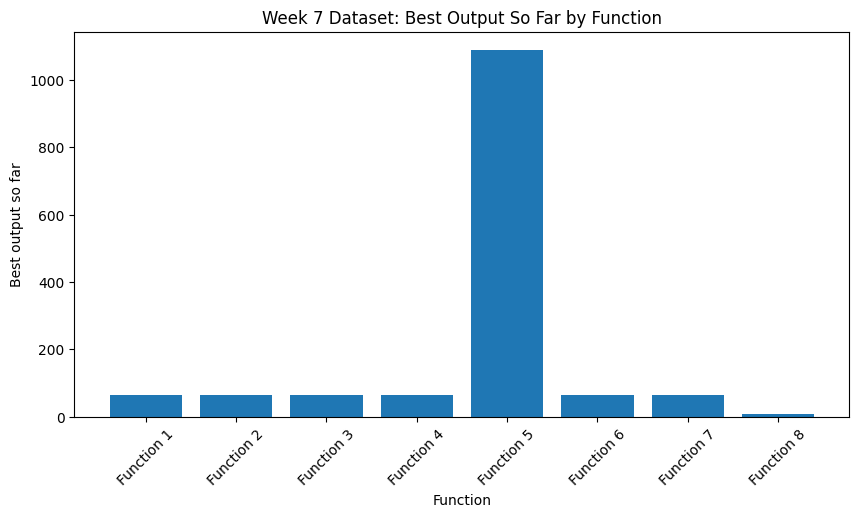

In [93]:
# Plot best output by function

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    week_7_summary_df["Function"],
    week_7_summary_df["Best output so far"]
)

plt.xlabel("Function")
plt.ylabel("Best output so far")
plt.title("Week 7 Dataset: Best Output So Far by Function")
plt.xticks(rotation=45)
plt.show()


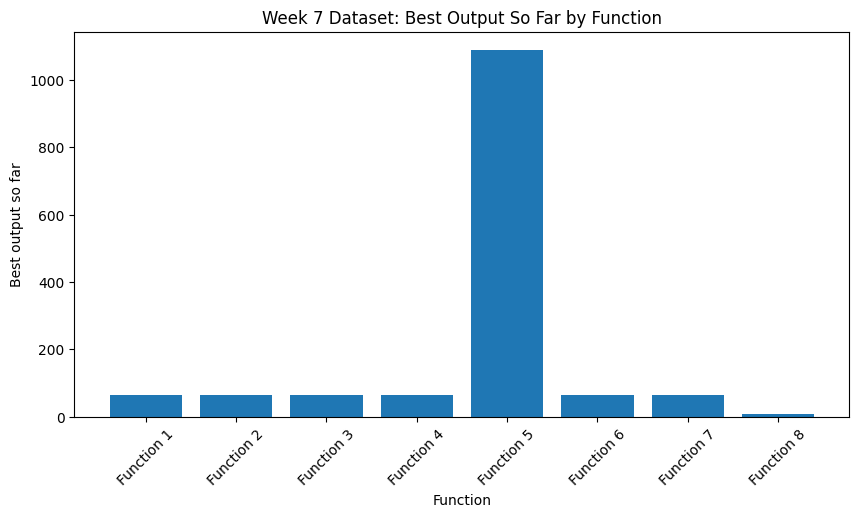

In [94]:
# Visualize best output so far

plt.figure(figsize=(10, 5))

plt.bar(
    week_7_summary_df["Function"],
    week_7_summary_df["Best output so far"]
)

plt.xlabel("Function")
plt.ylabel("Best output so far")
plt.title("Week 7 Dataset: Best Output So Far by Function")
plt.xticks(rotation=45)
plt.show()

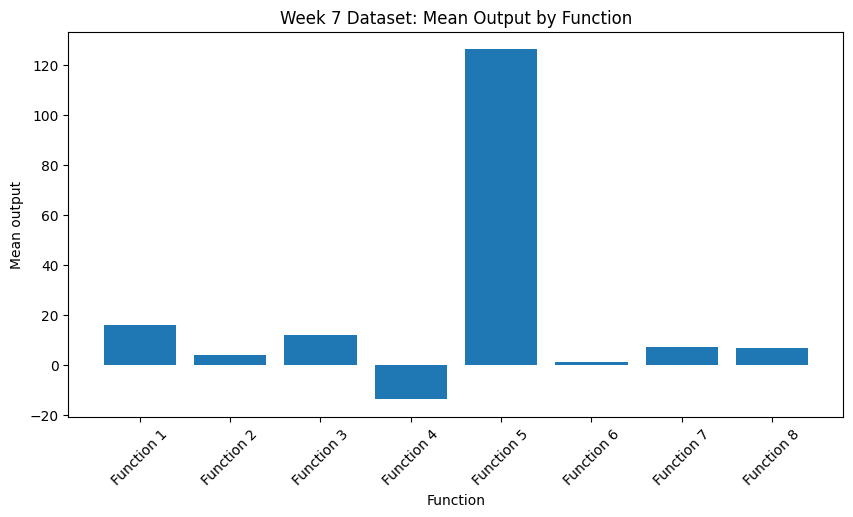

In [95]:
# Visualise mean output by function

plt.figure(figsize=(10, 5))

plt.bar(
    week_7_summary_df["Function"],
    week_7_summary_df["Mean output"]
)

plt.xlabel("Function")
plt.ylabel("Mean output")
plt.title("Week 7 Dataset: Mean Output by Function")
plt.xticks(rotation=45)
plt.show()

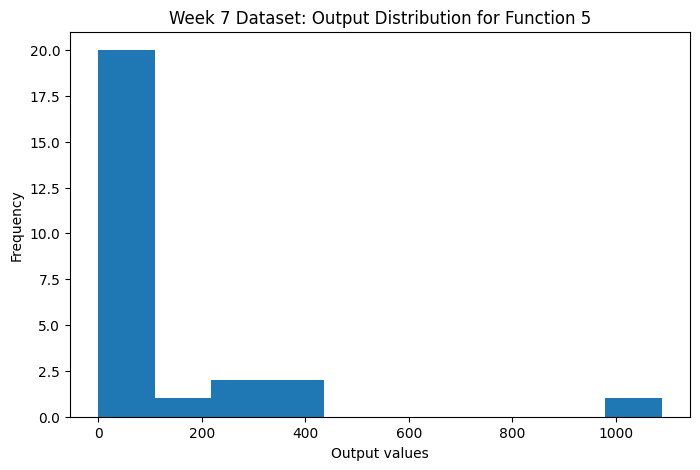

In [96]:
# Plot the output distribution for each function

f = 5

y = np.load(
    week_7_path + f"/function_{f}_outputs.npy",
    allow_pickle=True
).astype(float)

plt.figure(figsize=(8, 5))
plt.hist(y, bins=10)

plt.xlabel("Output values")
plt.ylabel("Frequency")
plt.title(f"Week 7 Dataset: Output Distribution for Function {f}")
plt.show()

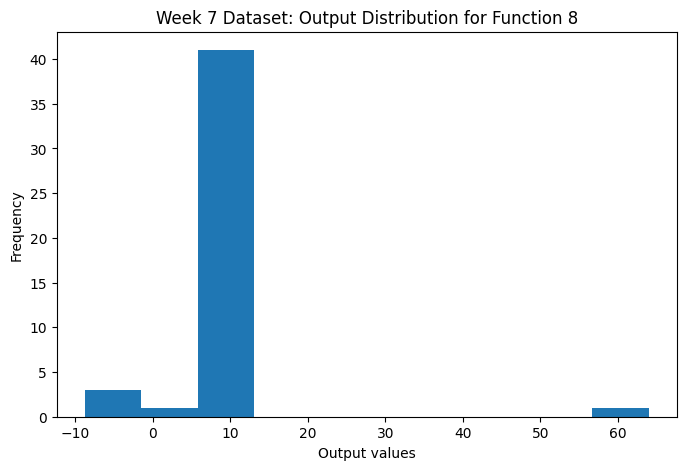

In [97]:
f = 8

y = np.load(
    week_7_path + f"/function_{f}_outputs.npy",
    allow_pickle=True
).astype(float)

plt.figure(figsize=(8, 5))
plt.hist(y, bins=10)

plt.xlabel("Output values")
plt.ylabel("Frequency")
plt.title(f"Week 7 Dataset: Output Distribution for Function {f}")
plt.show()

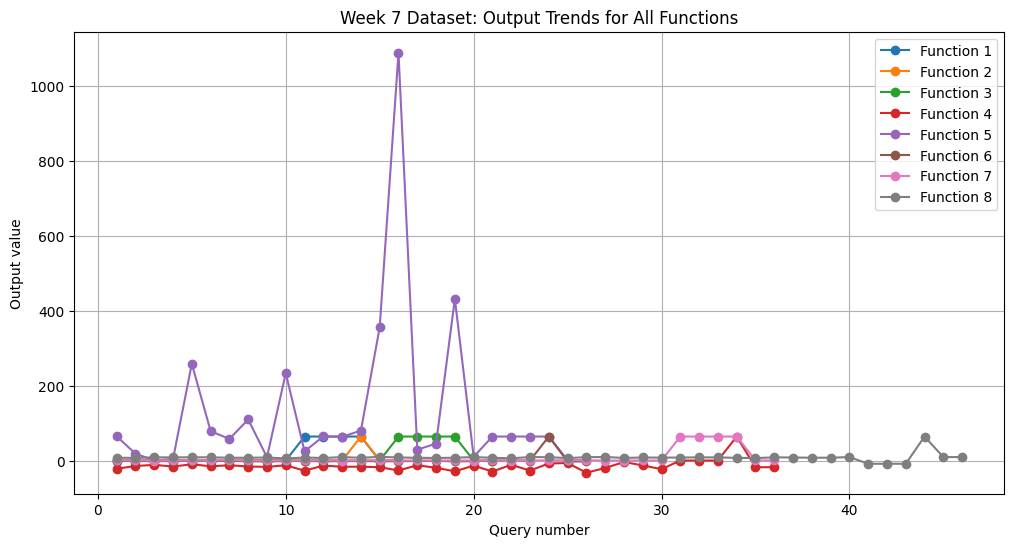

In [98]:
# Plot all function output trends on one graph

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

for f in range(1, 9):
    y_raw = np.load(
        week_7_path + f"/function_{f}_outputs.npy",
        allow_pickle=True
    )

    y = clean_y(y_raw)

    query_numbers = np.arange(1, len(y) + 1)

    plt.plot(query_numbers, y, marker="o", label=f"Function {f}")

plt.xlabel("Query number")
plt.ylabel("Output value")
plt.title("Week 7 Dataset: Output Trends for All Functions")
plt.legend()
plt.grid(True)
plt.show()

In [99]:
# Best Query Point

import pandas as pd
import numpy as np

best_points_expanded = []

expected_dims = {
    1: 2,
    2: 2,
    3: 3,
    4: 4,
    5: 4,
    6: 5,
    7: 6,
    8: 8
}

for f in range(1, 9):
    X_raw = np.load(
        week_7_path + f"/function_{f}_inputs.npy",
        allow_pickle=True
    )

    y_raw = np.load(
        week_7_path + f"/function_{f}_outputs.npy",
        allow_pickle=True
    )

    expected_dim = expected_dims[f]

    X, valid_indices, bad_rows = clean_X_with_expected_dim(X_raw, expected_dim)
    y = clean_y(y_raw)

    y_valid = y[valid_indices]

    best_index_inside_clean_data = np.argmax(y_valid)
    original_best_index = valid_indices[best_index_inside_clean_data]

    best_query_point = X[best_index_inside_clean_data]
    best_output = y_valid[best_index_inside_clean_data]

    row = {
        "Function": f"Function {f}",
        "Best point index": original_best_index,
        "Best output": best_output,
        "Bad rows removed": len(bad_rows)
    }

    # Add each query-point value as a separate column
    for i, value in enumerate(best_query_point):
        row[f"x{i+1}"] = value

    best_points_expanded.append(row)

best_points_expanded_df = pd.DataFrame(best_points_expanded)

# Show all columns clearly
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

best_points_expanded_df

,Function,Best point index,Best output,Bad rows removed,x1,x2,x3,x4,x5,x6,x7,x8
0,Function 1,10,64.000000,0,0.374540,0.950714,NaN,NaN,NaN,NaN,NaN,NaN
1,Function 2,13,64.000000,0,0.374540,0.950714,NaN,NaN,NaN,NaN,NaN,NaN
2,Function 3,15,64.000000,0,0.444444,0.666666,0.333333,NaN,NaN,NaN,NaN,NaN
3,Function 4,33,64.000000,0,0.555555,0.444444,0.222222,0.111111,NaN,NaN,NaN,NaN
4,Function 5,15,1088.859618,0,0.224189,0.846480,0.879484,0.878516,NaN,NaN,NaN,NaN
5,Function 6,23,64.000000,0,0.728186,0.154693,0.732552,0.693997,0.564013,NaN,NaN,NaN
6,Function 7,30,64.000000,0,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,NaN,NaN
7,Function 8,14,9.598482,1,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085


In [100]:
# Summary Table

summary = []

for f in range(1, 9):
    X_raw = np.load(
        week_7_path + f"/function_{f}_inputs.npy",
        allow_pickle=True
    )

    y_raw = np.load(
        week_7_path + f"/function_{f}_outputs.npy",
        allow_pickle=True
    )

    expected_dim = {
        1: 2,
        2: 2,
        3: 3,
        4: 4,
        5: 4,
        6: 5,
        7: 6,
        8: 8
    }[f]

    X, valid_indices, bad_rows = clean_X_with_expected_dim(X_raw, expected_dim)
    y = clean_y(y_raw)
    y_valid = y[valid_indices]

    summary.append({
        "Function": f"Function {f}",
        "Clean input shape": X.shape,
        "Clean output shape": y_valid.shape,
        "Expected dimensions": expected_dim,
        "Bad rows removed": len(bad_rows),
        "Best output so far": np.max(y_valid),
        "Worst output so far": np.min(y_valid),
        "Mean output": np.mean(y_valid),
        "Median output": np.median(y_valid),
        "Standard deviation": np.std(y_valid),
        "Best point index": valid_indices[np.argmax(y_valid)]
    })

week_7_summary_df = pd.DataFrame(summary)
week_7_summary_df

,Function,Clean input shape,Clean output shape,Expected dimensions,Bad rows removed,Best output so far,Worst output so far,Mean output,Median output,Standard deviation,Best point index
0,Function 1,"(16, 2)","(16,)",2,0,64.000000,-0.003606,15.999775,3.114928e-48,27.712943,10
1,Function 2,"(16, 2)","(16,)",2,0,64.000000,-0.065624,4.171769,2.178726e-01,15.448865,13
2,Function 3,"(21, 3)","(21,)",3,0,64.000000,-0.398926,12.108462,-5.739710e-02,25.171198,15
3,Function 4,"(36, 4)","(36,)",4,0,64.000000,-32.625660,-13.586270,-1.575674e+01,15.353443,33
4,Function 5,"(26, 4)","(26,)",4,0,1088.859618,0.112940,126.281452,6.400000e+01,220.626598,15
5,Function 6,"(26, 5)","(26,)",5,0,64.000000,-2.571170,1.111952,-1.332899e+00,12.596411,23
6,Function 7,"(36, 6)","(36,)",6,0,64.000000,0.002701,7.304716,9.795888e-02,20.046708,30
7,Function 8,"(45, 8)","(45,)",8,1,9.598482,-8.727516,6.771237,7.854541e+00,4.246066,14


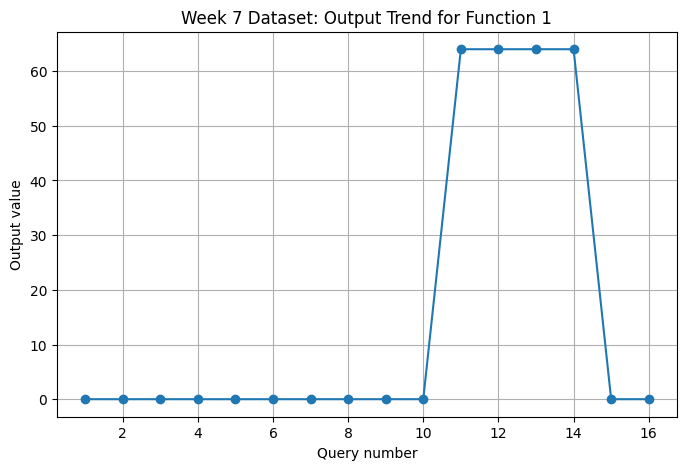

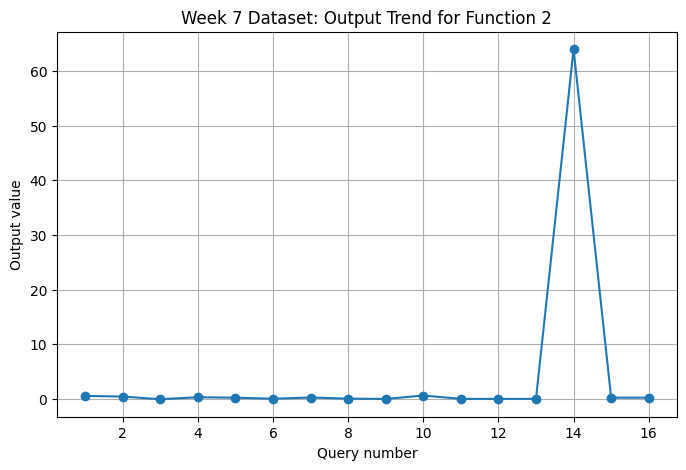

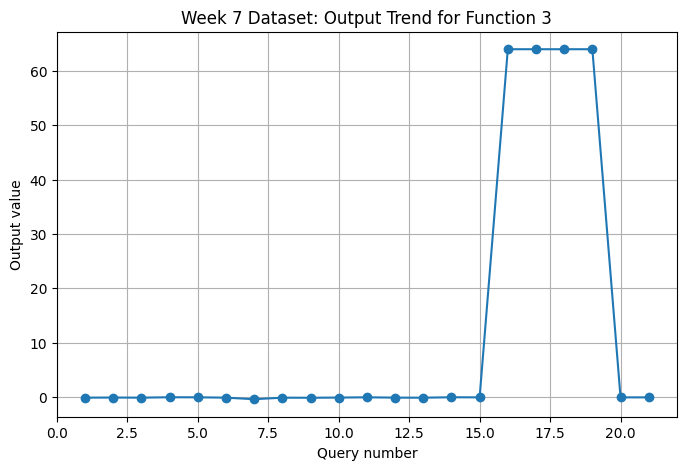

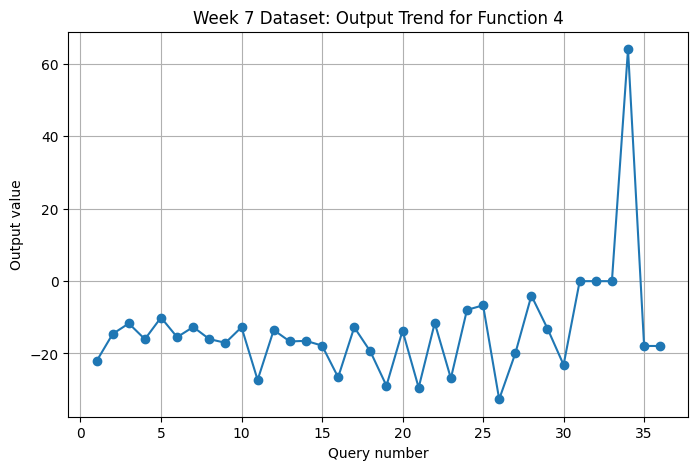

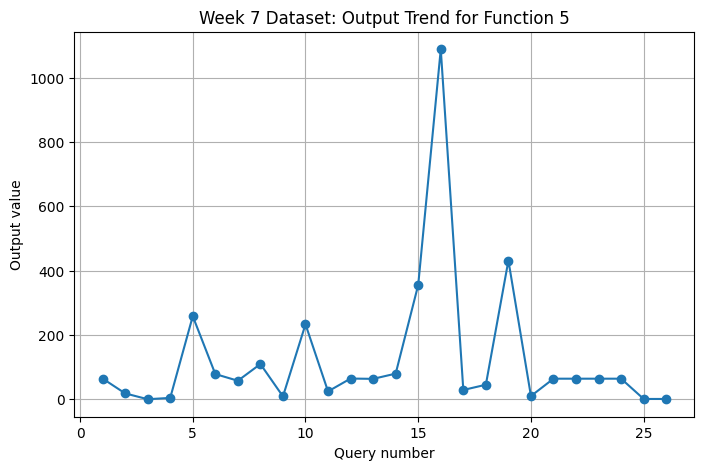

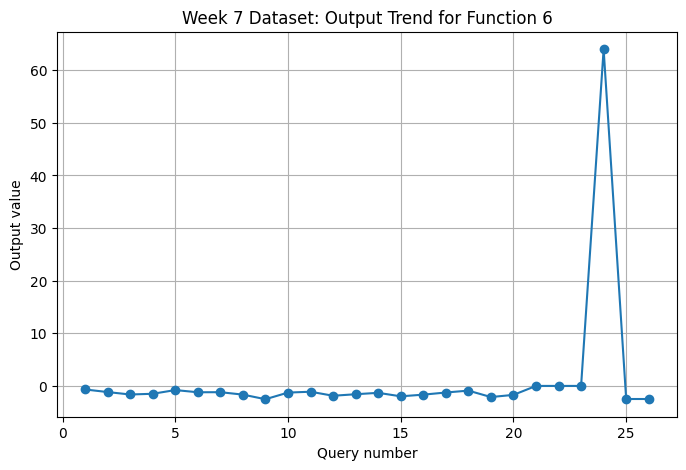

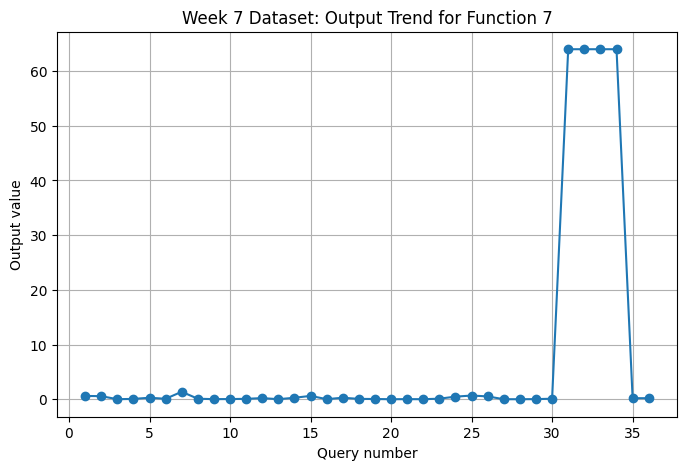

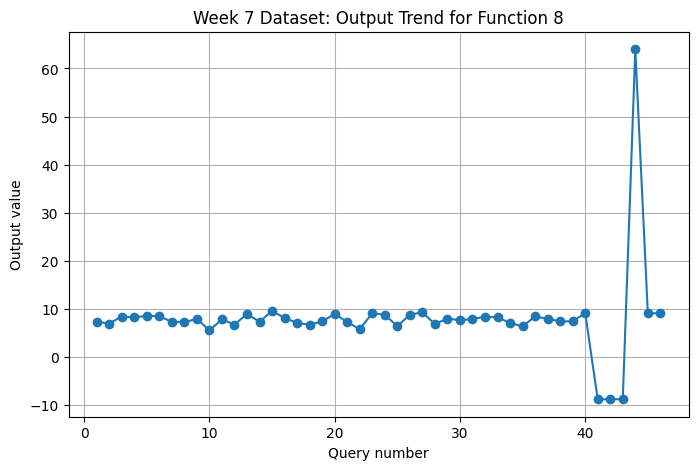

In [101]:
# Plot all functions separately

for f in range(1, 9):
    y_raw = np.load(
        week_7_path + f"/function_{f}_outputs.npy",
        allow_pickle=True
    )

    y = clean_y(y_raw)

    query_numbers = np.arange(1, len(y) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(query_numbers, y, marker="o")

    plt.xlabel("Query number")
    plt.ylabel("Output value")
    plt.title(f"Week 7 Dataset: Output Trend for Function {f}")
    plt.grid(True)
    plt.show()

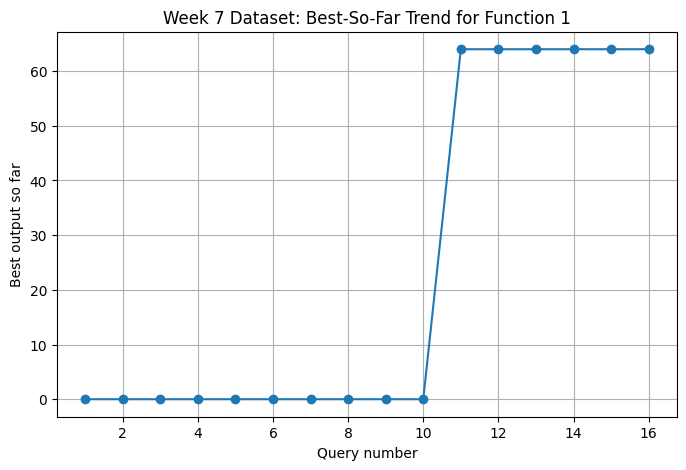

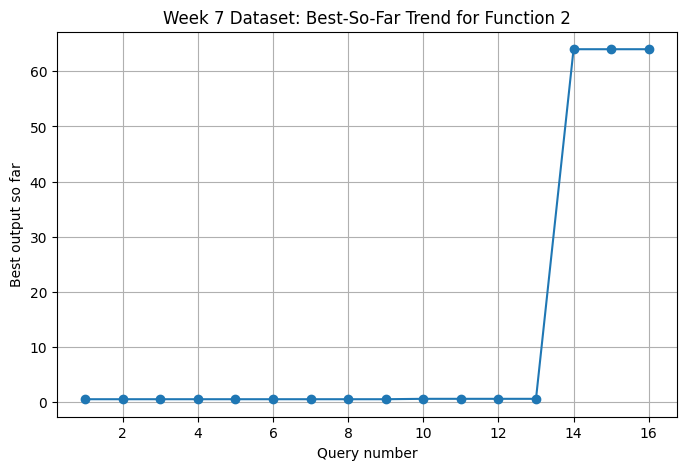

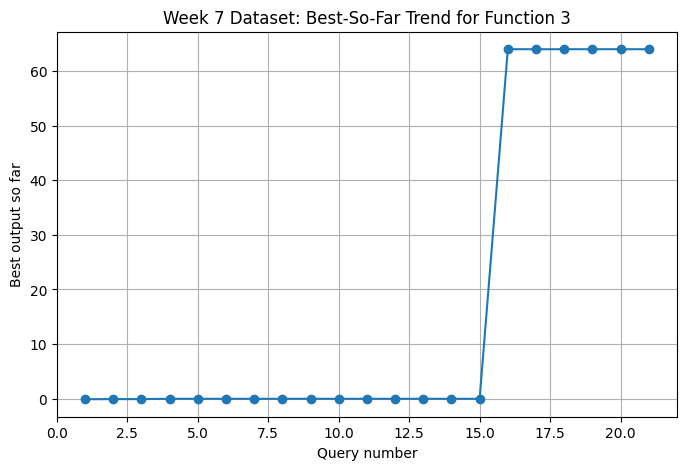

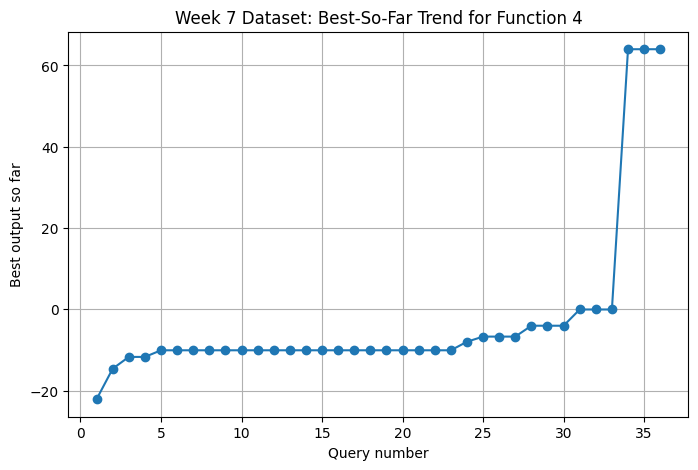

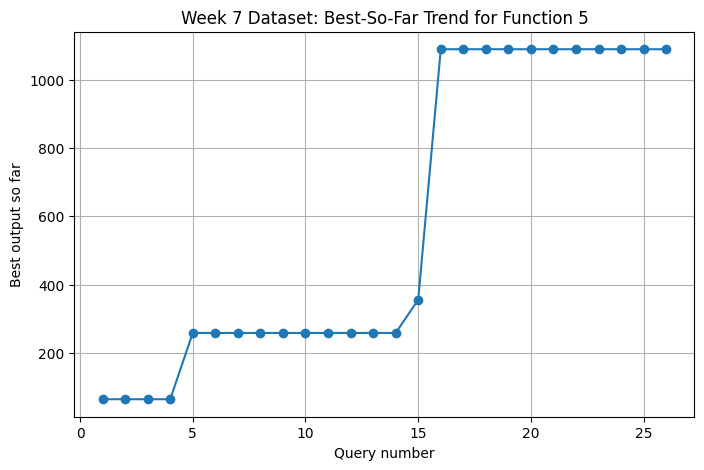

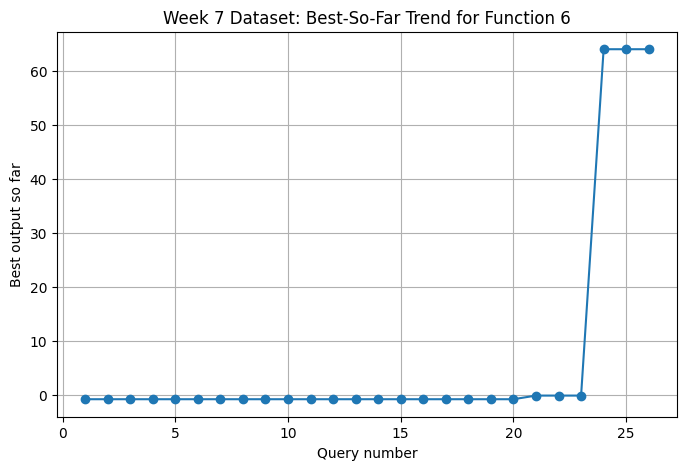

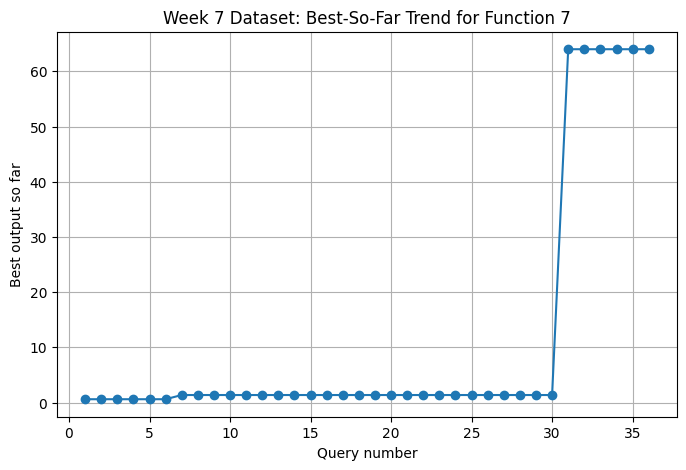

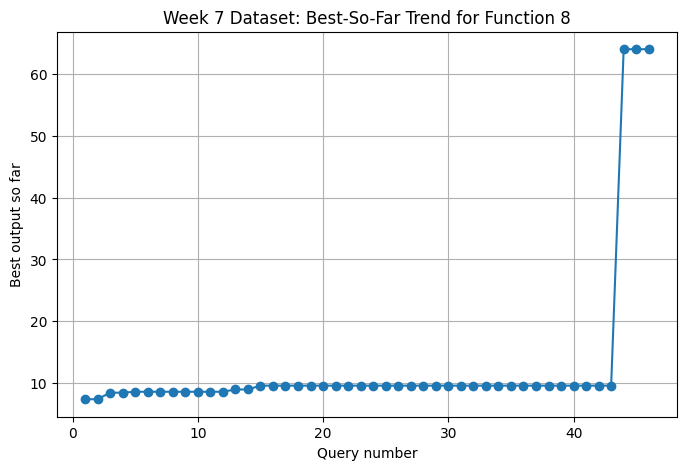

In [102]:
# Plot best-so-far trend for each function

for f in range(1, 9):
    y_raw = np.load(
        week_7_path + f"/function_{f}_outputs.npy",
        allow_pickle=True
    )

    y = clean_y(y_raw)

    best_so_far = np.maximum.accumulate(y)
    query_numbers = np.arange(1, len(y) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(query_numbers, best_so_far, marker="o")

    plt.xlabel("Query number")
    plt.ylabel("Best output so far")
    plt.title(f"Week 7 Dataset: Best-So-Far Trend for Function {f}")
    plt.grid(True)
    plt.show()

In [103]:
# Week_7_Strategy for My BO

The main strategy for week 7 is to go back and exploit around
The best-performing region identified so far

1. Load Week 7 dataset
2. Clean X and y
3. Fit GP for Functions 1–4 and 6–8
4. Use manual reasoning for Function 5
5. Print the final Week 7 query points clearly

In [123]:
# ================================
# CLEAN WEEK 7 QUERY GENERATION
# ================================

import numpy as np
import re
import warnings

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning

# Hide GP convergence warnings for cleaner output
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# -------------------------------
# 1. Cleaning functions
# -------------------------------

def clean_X_with_expected_dim(X, expected_dim):
    clean_rows = []
    valid_indices = []
    bad_rows = []

    for i, row in enumerate(X):
        try:
            arr = np.array(row, dtype=float).flatten()
        except:
            text = str(row)
            numbers = re.findall(r"[-+]?\d*\.?\d+(?:e[-+]?\d+)?", text)
            arr = np.array([float(n) for n in numbers])

        if arr.size == expected_dim:
            clean_rows.append(arr)
            valid_indices.append(i)
        else:
            bad_rows.append((i, arr.size, arr))

    return np.vstack(clean_rows), np.array(valid_indices), bad_rows


def clean_y(y):
    values = []

    for value in y:
        try:
            values.append(float(value))
        except:
            text = str(value)
            numbers = re.findall(r"[-+]?\d*\.?\d+(?:e[-+]?\d+)?", text)
            values.append(float(numbers[-1]))

    return np.array(values, dtype=float)


# -------------------------------
# 2. Settings
# -------------------------------

week_7_path = "/content/week_7_data"

expected_dims = {
    1: 2,
    2: 2,
    3: 3,
    4: 4,
    5: 4,
    6: 5,
    7: 6,
    8: 8
}

# Exploration/exploitation setting
kappa_settings = {
    1: 2,
    2: 2,
    3: 2,
    4: 2,
    6: 2,
    7: 2,
    8: 2
}

week_7_queries = {}

# -------------------------------
# 3. Generate queries using GP-UCB
# -------------------------------

for fn in range(1, 9):

    # Function 5: manual reasoning
    if fn == 5:
        week_7_queries[5] = np.array([0.000000, 0.000000, 0.000000, 0.000000])
        continue

    # Load raw data
    X_raw = np.load(
        week_7_path + f"/function_{fn}_inputs.npy",
        allow_pickle=True
    )

    y_raw = np.load(
        week_7_path + f"/function_{fn}_outputs.npy",
        allow_pickle=True
    )

    # Clean X and y
    expected_dim = expected_dims[fn]

    X, valid_indices, bad_rows = clean_X_with_expected_dim(
        X_raw,
        expected_dim
    )

    y = clean_y(y_raw)
    y = y[valid_indices]

    # Scale X for GP
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # GP model
    kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1e-5)

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        random_state=42
    )

    gp.fit(X_scaled, y)

    # Candidate search
    candidates = np.random.rand(5000, expected_dim)
    candidates_scaled = scaler.transform(candidates)

    mu, sigma = gp.predict(candidates_scaled, return_std=True)

    # UCB acquisition function
    kappa = kappa_settings[fn]
    ucb = mu + kappa * sigma

    best_idx = np.argmax(ucb)
    next_query = candidates[best_idx]

    # Keep within bounds and round
    next_query = np.clip(next_query, 0, 1)
    next_query = np.round(next_query, 6)

    week_7_queries[fn] = next_query

    print(f"Function {fn}")
    print("Clean X shape:", X.shape)
    print("Clean y shape:", y.shape)
    print("Bad rows removed:", len(bad_rows))
    print("Next query:", next_query)
    print("-" * 50)


# -------------------------------
# 4. Display final Week 7 queries
# -------------------------------

print("\nFINAL WEEK 7 QUERY POINTS")
print("=" * 50)

for fn in range(1, 9):
    query = week_7_queries[fn]
    print(f"Function {fn}: {' '.join(map(str, query))}")

Function 1
Clean X shape: (16, 2)
Clean y shape: (16,)
Bad rows removed: 0
Next query: [0.35042  0.999543]
--------------------------------------------------
Function 2
Clean X shape: (16, 2)
Clean y shape: (16,)
Bad rows removed: 0
Next query: [0.009675 0.999881]
--------------------------------------------------
Function 3
Clean X shape: (21, 3)
Clean y shape: (21,)
Bad rows removed: 0
Next query: [0.427731 0.66981  0.343678]
--------------------------------------------------
Function 4
Clean X shape: (36, 4)
Clean y shape: (36,)
Bad rows removed: 0
Next query: [0.096005 0.028299 0.033322 0.077327]
--------------------------------------------------
Function 6
Clean X shape: (26, 5)
Clean y shape: (26,)
Bad rows removed: 0
Next query: [0.68383  0.035248 0.777884 0.740721 0.62931 ]
--------------------------------------------------
Function 7
Clean X shape: (36, 6)
Clean y shape: (36,)
Bad rows removed: 0
Next query: [0.121173 0.544849 0.282921 0.037758 0.374065 0.591179]
-------------